In [3]:
from PIL import Image

img = Image.open("cat.jpeg")
print(type(img))
print(img.format)
print(img.mode)

<class 'PIL.JpegImagePlugin.JpegImageFile'>
JPEG
RGB


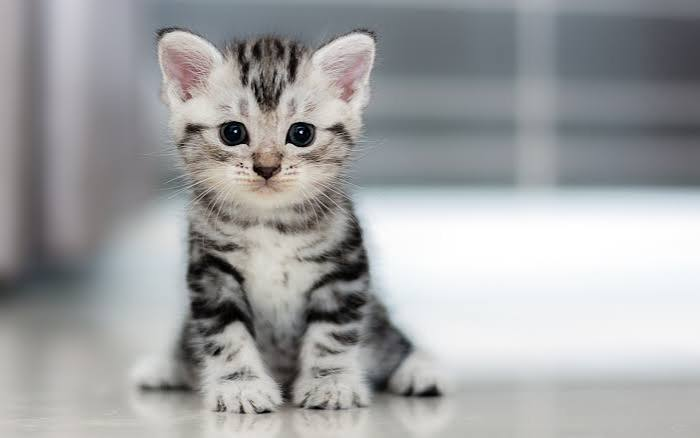

In [2]:
img

In [4]:
import cv2


img = cv2.imread("cat.jpeg")

print("Image shape:", img.shape)


if len(img.shape) == 3:
    print("Mode: Color (BGR)")
elif len(img.shape) == 2:
    print("Mode: Grayscale")

print("Data type:", img.dtype)

Image shape: (438, 700, 3)
Mode: Color (BGR)
Data type: uint8


# Image to numpy


In [5]:
from PIL import Image
import numpy as np

img = Image.open("cat.jpeg")

img_array = np.array(img)

print(type(img_array))
print(img_array.shape)

<class 'numpy.ndarray'>
(438, 700, 3)


# Image to tensor

In [1]:
from PIL import Image
from torchvision import transforms

img = Image.open("cat.jpeg")

transform = transforms.ToTensor()

tensor_img = transform(img)

print(type(tensor_img))
print(tensor_img.shape)

<class 'torch.Tensor'>
torch.Size([3, 438, 700])


# Normalization

In [4]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# Load image
img = Image.open("cat.jpeg")


img_array = np.array(img)

print("Before normalization")
print("Type:", type(img_array))
print("Shape:", img_array.shape)
print("Min pixel value:", img_array.min())
print("Max pixel value:", img_array.max())



Before normalization
Type: <class 'numpy.ndarray'>
Shape: (438, 700, 3)
Min pixel value: 0
Max pixel value: 255


In [5]:
# Normalize: 0-255 -> 0-1
img_array_norm = img_array / 255.0

print("\nAfter normalization")
print("Type:", type(img_array_norm))
print("Shape:", img_array_norm.shape)
print("Min pixel value:", img_array_norm.min())
print("Max pixel value:", img_array_norm.max())



After normalization
Type: <class 'numpy.ndarray'>
Shape: (438, 700, 3)
Min pixel value: 0.0
Max pixel value: 1.0


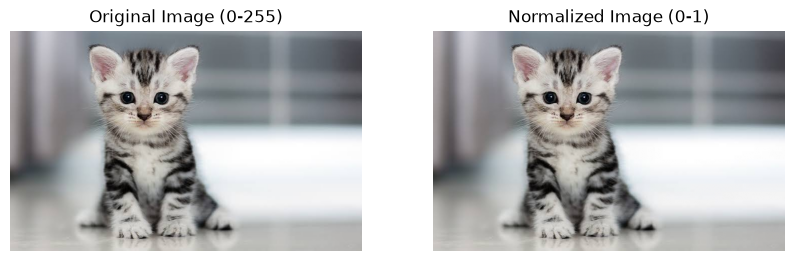

In [6]:

# original vs normalized image
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(img_array)
plt.title("Original Image (0-255)")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(img_array_norm)
plt.title("Normalized Image (0-1)")
plt.axis("off")

plt.show()

In [7]:
from PIL import Image
import numpy as np
import torch
import matplotlib.pyplot as plt

# Load image
img = Image.open("cat.jpeg")

# Convert to NumPy array
img_array = np.array(img)



In [8]:
# Convert to tensor
tensor_img = torch.tensor(img_array, dtype=torch.float32)

print("Before normalization")
print("Type:", type(tensor_img))
print("Shape:", tensor_img.shape)   # (H, W, C)
print("Min:", tensor_img.min().item())
print("Max:", tensor_img.max().item())

# Normalize: 0-255 -> 0-1
tensor_img = tensor_img / 255.0

print("\nAfter normalization")
print("Type:", type(tensor_img))
print("Shape:", tensor_img.shape)   # still (H, W, C)
print("Min:", tensor_img.min().item())
print("Max:", tensor_img.max().item())



Before normalization
Type: <class 'torch.Tensor'>
Shape: torch.Size([438, 700, 3])
Min: 0.0
Max: 255.0

After normalization
Type: <class 'torch.Tensor'>
Shape: torch.Size([438, 700, 3])
Min: 0.0
Max: 1.0



After permute to PyTorch format
Shape: torch.Size([3, 438, 700])


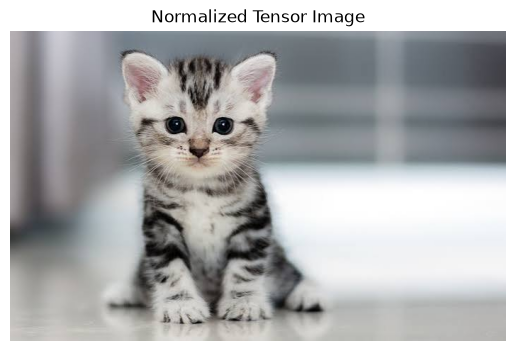

In [9]:
# Change to PyTorch format: (C, H, W)
tensor_img_chw = tensor_img.permute(2, 0, 1)

print("\nAfter permute to PyTorch format")
print("Shape:", tensor_img_chw.shape)   # (C, H, W)

# Display image again
plt.imshow(tensor_img)
plt.title("Normalized Tensor Image")
plt.axis("off")
plt.show()

NumPy array shape: (438, 700, 3)
NumPy min/max: 0 255
Normalized NumPy min/max: 0.0 1.0
Tensor shape before permute: torch.Size([438, 700, 3])
Tensor shape after permute: torch.Size([3, 438, 700])


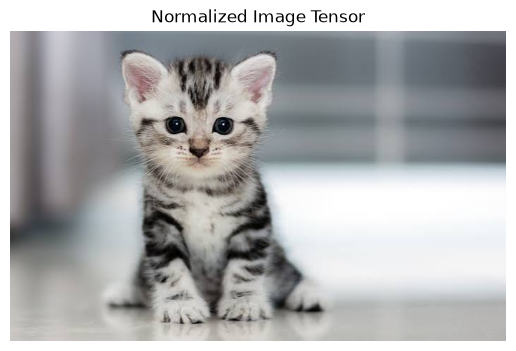

In [10]:
from PIL import Image
import numpy as np
import torch
import matplotlib.pyplot as plt

# Step 1: Load image
img = Image.open("cat.jpeg")

# Step 2: Convert image to NumPy array
img_array = np.array(img)
print("NumPy array shape:", img_array.shape)
print("NumPy min/max:", img_array.min(), img_array.max())

# Step 3: Normalize NumPy array
img_array_norm = img_array / 255.0
print("Normalized NumPy min/max:", img_array_norm.min(), img_array_norm.max())

# Step 4: Convert normalized array to tensor
tensor_img = torch.tensor(img_array_norm, dtype=torch.float32)
print("Tensor shape before permute:", tensor_img.shape)  # (H, W, C)

# Step 5: Convert to PyTorch format
tensor_img = tensor_img.permute(2, 0, 1)
print("Tensor shape after permute:", tensor_img.shape)   # (C, H, W)

# Step 6: Show image
plt.imshow(tensor_img.permute(1, 2, 0))
plt.title("Normalized Image Tensor")
plt.axis("off")
plt.show()